# 02 · Exploratory Data Analysis — Restaurants de Niamey
**Entrée :** `data/processed/restaurants_clean.csv`  
**Objectif :** Comprendre la structure du marché, identifier les opportunités et produire les insights qui alimenteront le notebook de recommandation.

### Plan d'analyse
1. Vue d'ensemble statistique
2. Analyse univariée (distributions)
3. Analyse bivariée & multivariée
4. Requêtes SQL analytiques (DuckDB)
5. Tests statistiques (Kruskal-Wallis)
6. Analyse des niches de marché *(market gap)*
7. Synthèse des findings


## 0 · Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import duckdb
from scipy import stats
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

# ── Style ──────────────────────────────────────────────────────────────────
PALETTE = {
    "primary":   "#2563EB",
    "secondary": "#7C3AED",
    "success":   "#059669",
    "warning":   "#D97706",
    "danger":    "#DC2626",
    "neutral":   "#94A3B8",
    "bg":        "#F8FAFC",
}
CAT_COLORS = [
    "#3B82F6","#8B5CF6","#F59E0B","#10B981",
    "#EC4899","#F97316","#14B8A6","#94A3B8","#EF4444","#6366F1",
]

plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"],
    "axes.facecolor":   PALETTE["bg"],
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "grid.linestyle":   "--",
    "font.size":        11,
    "axes.titleweight": "bold",
    "axes.titlesize":   13,
})

PROC = Path("../data/processed/restaurants_clean.csv")
FIG_DIR = Path("../data/processed/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("✅ Imports OK (Native Matplotlib positioning)")

✅ Imports OK (Native Matplotlib positioning)


## 1 · Chargement & vue d'ensemble

In [2]:
df = pd.read_csv(PROC, encoding="utf-8-sig")

print(f"Shape : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}\n")
df.head(3)


Shape : (490, 21)
Colonnes : ['name', 'category', 'category_clean', 'is_chain', 'street', 'city', 'state', 'country_code', 'has_address', 'is_plus_code', 'phone', 'has_phone', 'website', 'has_website', 'website_valid', 'score_raw', 'reviews_count', 'score_bayes', 'reliability_tier', 'completeness_score', 'maps_url']



,name,category,category_clean,is_chain,street,city,state,country_code,has_address,is_plus_code,phone,has_phone,website,has_website,website_valid,score_raw,reviews_count,score_bayes,reliability_tier,completeness_score,maps_url
0,Amandine,Restaurant,Restaurant,False,G476+RX4,Niamey,NaN,NE,True,True,+227 90 19 49 08,True,https://www.facebook.com/restoamandine?mibexti...,True,True,3.900,1408,3.906,5_very_high,4,https://www.google.com/maps/search/?api=1&quer...
1,Bab Salam Maurice Delens,Restauration rapide,Fast food,False,G3MW+WR4,Niamey,NaN,NE,True,True,+227 91 95 47 48,True,NaN,False,False,3.900,1351,3.906,5_very_high,3,https://www.google.com/maps/search/?api=1&quer...
2,Rawda,Restaurant,Restaurant,False,"G4H4+8R9, Bd du Zarmaganda",Niamey,NaN,NE,True,True,+227 88 66 80 20,True,NaN,False,False,3.800,883,3.813,5_very_high,3,https://www.google.com/maps/search/?api=1&quer...


In [3]:
# Statistiques descriptives — champs numériques clés
desc = df[["score_raw","score_bayes","reviews_count","completeness_score"]].describe().T
desc["median"] = df[["score_raw","score_bayes","reviews_count","completeness_score"]].median()
desc["skew"]   = df[["score_raw","score_bayes","reviews_count","completeness_score"]].skew()
print(desc.round(3).to_string())


                     count   mean     std   min   25%   50%    75%      max  median   skew
score_raw          373.000  4.107   0.841 1.000 3.800 4.100  4.800    5.000   4.100 -1.453
score_bayes        372.000  4.085   0.127 3.514 4.033 4.104  4.149    4.835   4.104 -0.280
reviews_count      490.000 29.845 118.503 0.000 1.000 2.000 10.000 1408.000   2.000  7.947
completeness_score 490.000  2.343   0.822 0.000 2.000 2.000  3.000    4.000   2.000 -0.309


In [4]:
# Résumé rapide en une ligne par indicateur clé
con = duckdb.connect()
con.register("resto", df)

summary = con.execute("""
    SELECT
        COUNT(*)                                          AS nb_restaurants,
        ROUND(AVG(score_bayes),3)                        AS score_bayes_moyen,
        ROUND(MEDIAN(reviews_count),0)                   AS median_avis,
        ROUND(AVG(CASE WHEN reviews_count >= 20
                       THEN score_bayes END), 3)         AS score_fiable,
        COUNT(DISTINCT category_clean)                   AS nb_categories,
        SUM(has_website::int)                            AS avec_site_web,
        ROUND(SUM(has_website::int)*100.0/COUNT(*),1)   AS pct_web
    FROM resto
""").df()
print(summary.T.to_string(header=False))


nb_restaurants    490.000
score_bayes_moyen   4.085
median_avis         2.000
score_fiable        4.008
nb_categories      15.000
avec_site_web      26.000
pct_web             5.300


## 2 · Analyse univariée

### 2.1 Distribution des notes — brutes vs bayésiennes


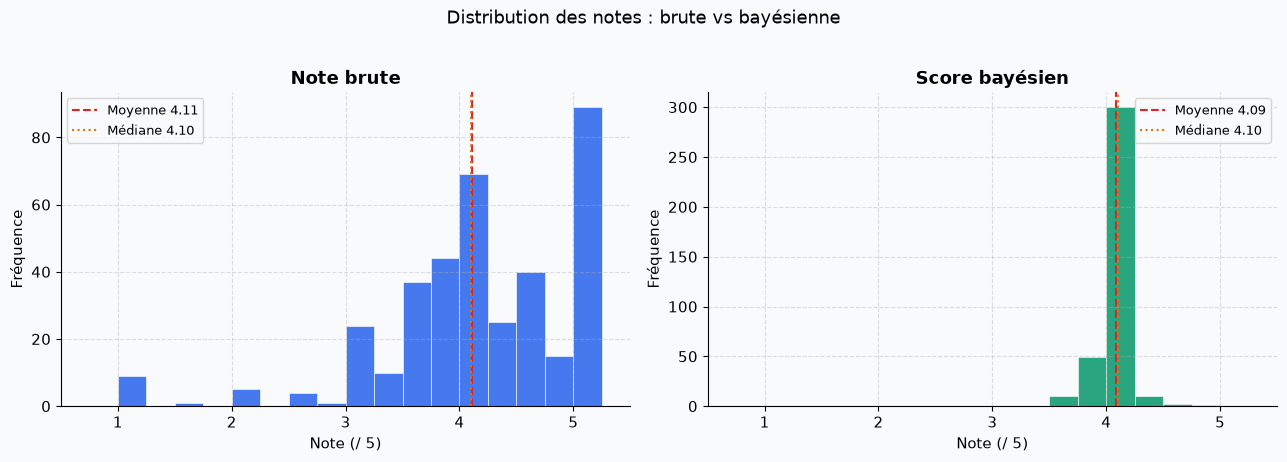

Shapiro-Wilk (score_bayes, n=200) : W=0.8870, p=4.0473e-11
→ Distribution non-normale


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Distribution des notes : brute vs bayésienne", y=1.02)

bins = np.arange(0.75, 5.51, 0.25)

for ax, col, label, color in zip(
    axes,
    ["score_raw", "score_bayes"],
    ["Note brute", "Score bayésien"],
    [PALETTE["primary"], PALETTE["success"]],
):
    data = df[col].dropna()
    ax.hist(data, bins=bins, color=color, edgecolor="white", linewidth=0.5, alpha=0.85)
    ax.axvline(data.mean(),   color=PALETTE["danger"],  lw=1.5, ls="--", label=f"Moyenne {data.mean():.2f}")
    ax.axvline(data.median(), color=PALETTE["warning"], lw=1.5, ls=":",  label=f"Médiane {data.median():.2f}")
    ax.set_title(label)
    ax.set_xlabel("Note (/ 5)")
    ax.set_ylabel("Fréquence")
    ax.set_xlim(0.5, 5.5)
    ax.legend(fontsize=9)

plt.tight_layout()
savefig("01_score_distribution")

# Test de normalité (Shapiro-Wilk sur échantillon)
sample = df["score_bayes"].dropna().sample(min(200, len(df)), random_state=42)
stat, p = stats.shapiro(sample)
print(f"Shapiro-Wilk (score_bayes, n=200) : W={stat:.4f}, p={p:.4e}")
print("→ Distribution non-normale" if p < 0.05 else "→ Distribution normale")


### 2.2 Distribution des avis — longue traîne

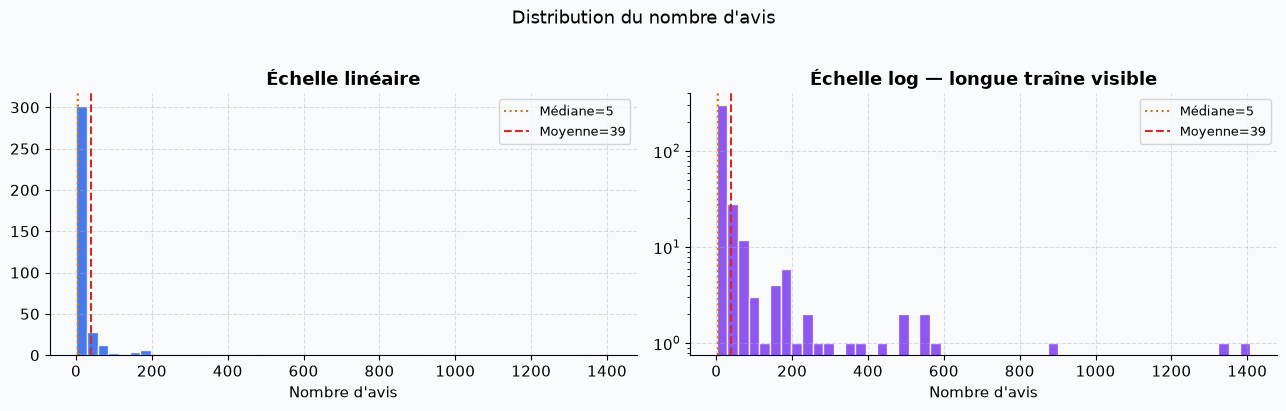

P50   : 5 avis
P75   : 17 avis
P90   : 63 avis
P99   : 565 avis
Max   : 1408 avis (Amandine)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Distribution du nombre d'avis", y=1.02)

rc = df[df["reviews_count"] > 0]["reviews_count"]

axes[0].hist(rc, bins=50, color=PALETTE["primary"], edgecolor="white", alpha=0.85)
axes[0].set_title("Échelle linéaire")
axes[0].set_xlabel("Nombre d'avis")

axes[1].hist(rc, bins=50, color=PALETTE["secondary"], edgecolor="white", alpha=0.85)
axes[1].set_yscale("log")
axes[1].set_title("Échelle log — longue traîne visible")
axes[1].set_xlabel("Nombre d'avis")

for ax in axes:
    ax.axvline(rc.median(), color=PALETTE["warning"], lw=1.5, ls=":", label=f"Médiane={rc.median():.0f}")
    ax.axvline(rc.mean(),   color=PALETTE["danger"],  lw=1.5, ls="--", label=f"Moyenne={rc.mean():.0f}")
    ax.legend(fontsize=9)

plt.tight_layout()
savefig("02_reviews_distribution")

print(f"P50   : {rc.quantile(.50):.0f} avis")
print(f"P75   : {rc.quantile(.75):.0f} avis")
print(f"P90   : {rc.quantile(.90):.0f} avis")
print(f"P99   : {rc.quantile(.99):.0f} avis")
print(f"Max   : {rc.max()} avis ({df.loc[df['reviews_count'].idxmax(),'name']})")


### 2.3 Répartition par catégorie

In [7]:
cat_stats = (
    df.groupby("category_clean")
      .agg(
          nb=("name", "count"),
          score_bayes=("score_bayes", "mean"),
          median_avis=("reviews_count", "median"),
      )
      .sort_values("nb", ascending=False)
      .round(3)
)
cat_stats["pct"] = (cat_stats["nb"] / len(df) * 100).round(1)
print(cat_stats.to_string())


                           nb  score_bayes  median_avis    pct
category_clean                                                
Restaurant                332        4.082        3.000 67.800
Fast food                  58        4.096        1.000 11.800
Autre                      25        4.113        2.000  5.100
Restaurant africain        22        4.006        2.000  4.500
Café / Lounge              19        4.101        3.000  3.900
Grillades / BBQ            10        4.109        3.000  2.000
Pizzeria                    7        4.125        1.000  1.400
Restaurant halal            4        4.070        2.500  0.800
Restaurant indien           3        4.148       16.000  0.600
Bar                         2        4.099       24.000  0.400
Boulangerie / Pâtisserie    2        4.026      197.500  0.400
Sandwich                    2        4.150        3.500  0.400
Kebab                       2        4.188        4.500  0.400
Hôtel                       1        4.018      187.000

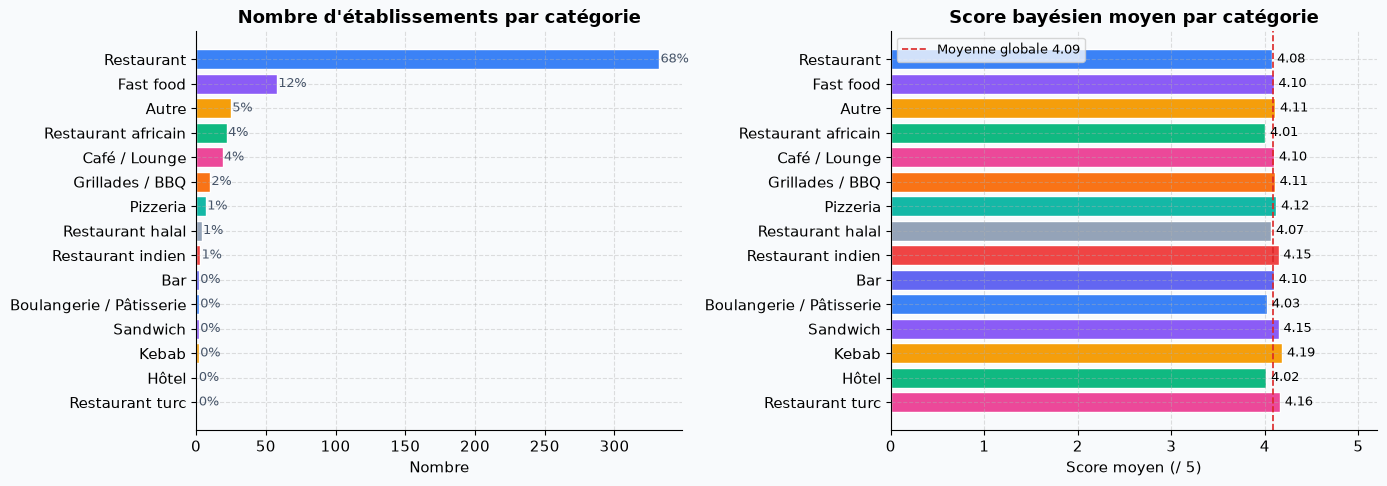

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot nb restaurants
cats = cat_stats.index.tolist()
colors = CAT_COLORS[:len(cats)]

axes[0].barh(cats, cat_stats["nb"], color=colors, edgecolor="white")
axes[0].set_title("Nombre d'établissements par catégorie")
axes[0].set_xlabel("Nombre")
axes[0].invert_yaxis()
for i, (v, pct) in enumerate(zip(cat_stats["nb"], cat_stats["pct"])):
    axes[0].text(v + 1, i, f"{pct:.0f}%", va="center", fontsize=9, color="#475569")

# Score bayésien moyen par catégorie
axes[1].barh(cats, cat_stats["score_bayes"], color=colors, edgecolor="white")
axes[1].set_title("Score bayésien moyen par catégorie")
axes[1].set_xlabel("Score moyen (/ 5)")
axes[1].axvline(df["score_bayes"].mean(), color=PALETTE["danger"], lw=1.2, ls="--",
                label=f"Moyenne globale {df['score_bayes'].mean():.2f}")
axes[1].invert_yaxis()
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 5.2)
for i, v in enumerate(cat_stats["score_bayes"]):
    axes[1].text(v + 0.05, i, f"{v:.2f}", va="center", fontsize=9)

plt.tight_layout()
savefig("03_category_overview")


### 2.4 Niveaux de fiabilité

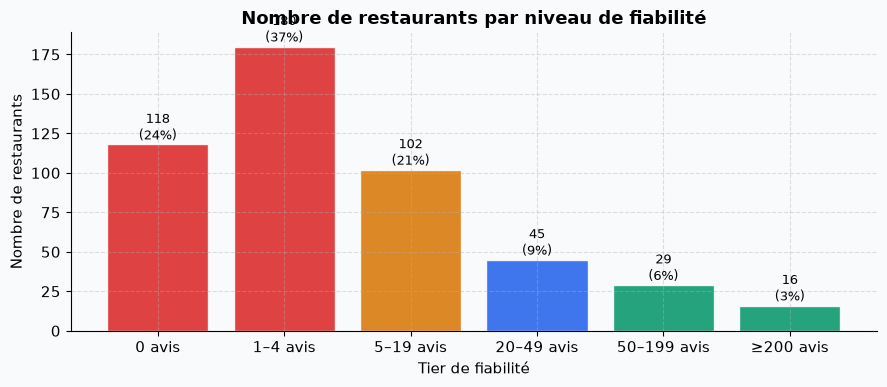

Restaurants avec ≥20 avis (analyse fiable) : 90


In [9]:
tier_order = ["0_no_reviews","1_very_low","2_low","3_medium","4_high","5_very_high"]
tier_labels = ["0 avis","1–4 avis","5–19 avis","20–49 avis","50–199 avis","≥200 avis"]
tier_counts = df["reliability_tier"].value_counts().reindex(tier_order).fillna(0)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(tier_labels, tier_counts.values,
              color=[PALETTE["danger"], PALETTE["danger"], PALETTE["warning"],
                     PALETTE["primary"], PALETTE["success"], PALETTE["success"]],
              edgecolor="white", alpha=0.87)
ax.set_title("Nombre de restaurants par niveau de fiabilité")
ax.set_ylabel("Nombre de restaurants")
ax.set_xlabel("Tier de fiabilité")
for bar, n in zip(bars, tier_counts.values):
    pct = n / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{int(n)}\n({pct:.0f}%)", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
savefig("04_reliability_tiers")
print(f"Restaurants avec ≥20 avis (analyse fiable) : {(df['reviews_count']>=20).sum()}")


## 3 · Analyse bivariée & multivariée

### 3.1 Score bayésien vs volume d'avis


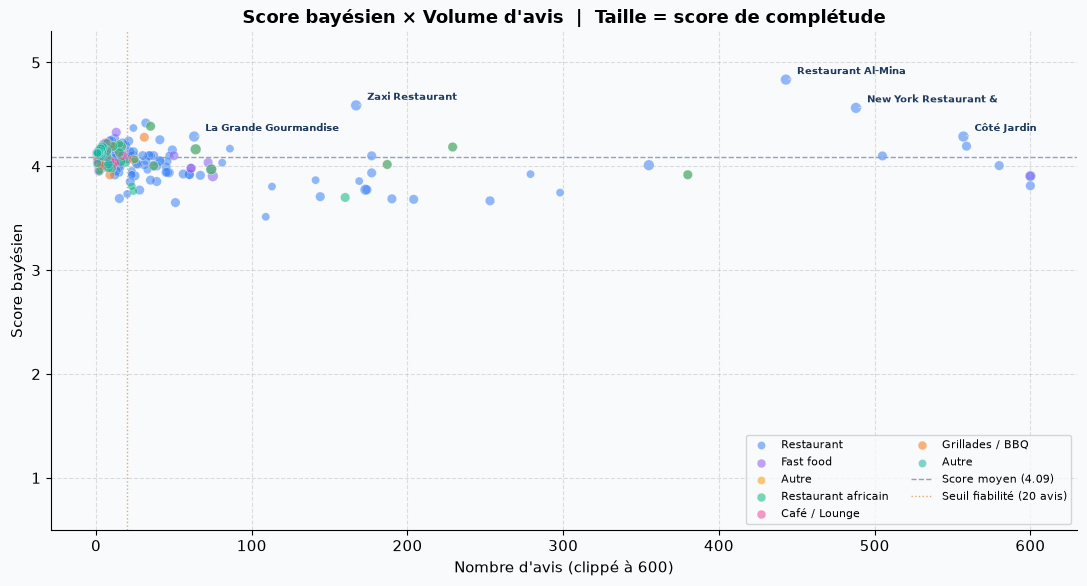

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))

# Colorer par catégorie (top 6)
top_cats = cat_stats.head(6).index.tolist()
df["cat_plot"] = df["category_clean"].where(df["category_clean"].isin(top_cats), "Autre")

for i, cat in enumerate(top_cats + ["Autre"]):
    sub = df[df["cat_plot"] == cat]
    ax.scatter(
        sub["reviews_count"].clip(upper=600),
        sub["score_bayes"],
        label=cat, s=sub["completeness_score"]*12 + 10,
        alpha=0.55, color=CAT_COLORS[i], edgecolors="white", linewidths=0.3
    )

ax.axhline(df["score_bayes"].mean(), color="#94A3B8", lw=1, ls="--",
           label=f"Score moyen ({df['score_bayes'].mean():.2f})")
ax.axvline(20, color=PALETTE["warning"], lw=1, ls=":", alpha=0.6,
           label="Seuil fiabilité (20 avis)")

ax.set_xlabel("Nombre d'avis (clippé à 600)")
ax.set_ylabel("Score bayésien")
ax.set_title("Score bayésien × Volume d'avis  |  Taille = score de complétude")
ax.legend(fontsize=8, loc="lower right", ncol=2)
ax.set_ylim(0.5, 5.3)

# Annotations top performers
top5 = df[df["reviews_count"] >= 50].nlargest(5, "score_bayes")
for _, row in top5.iterrows():
    ax.annotate(
        row["name"][:22], xy=(min(row["reviews_count"], 600), row["score_bayes"]),
        xytext=(8, 4), textcoords="offset points", fontsize=7.5,
        color="#1E3A5F", fontweight="bold",
        arrowprops=dict(arrowstyle="-", color="#CBD5E1", lw=0.8)
    )

plt.tight_layout()
savefig("05_score_vs_reviews")


### 3.2 Distribution des scores par catégorie (boxplot)

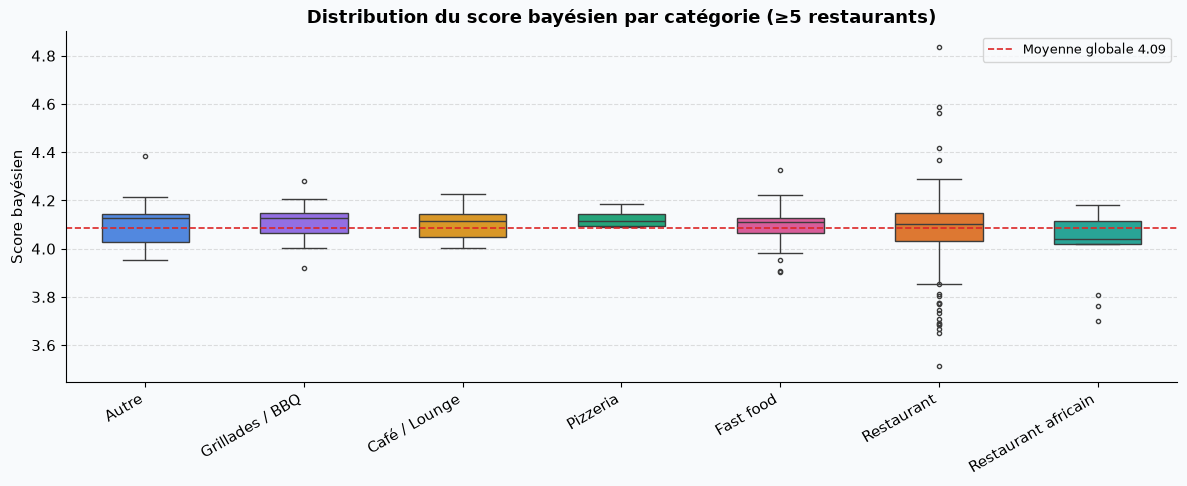

In [11]:
# Filtrer catégories avec au moins 5 restaurants
valid_cats = df["category_clean"].value_counts()[lambda x: x >= 5].index
df_box = df[df["category_clean"].isin(valid_cats)].copy()

# Trier par médiane décroissante
order = (df_box.groupby("category_clean")["score_bayes"]
               .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=df_box, x="category_clean", y="score_bayes",
    order=order, palette=CAT_COLORS[:len(order)],
    width=0.55, fliersize=3, linewidth=1, ax=ax
)
ax.set_title("Distribution du score bayésien par catégorie (≥5 restaurants)")
ax.set_xlabel("")
ax.set_ylabel("Score bayésien")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.axhline(df["score_bayes"].mean(), color=PALETTE["danger"], lw=1.2,
           ls="--", label=f"Moyenne globale {df['score_bayes'].mean():.2f}")
ax.legend(fontsize=9)
plt.tight_layout()
savefig("06_score_boxplot_category")


### 3.3 Corrélation — heatmap

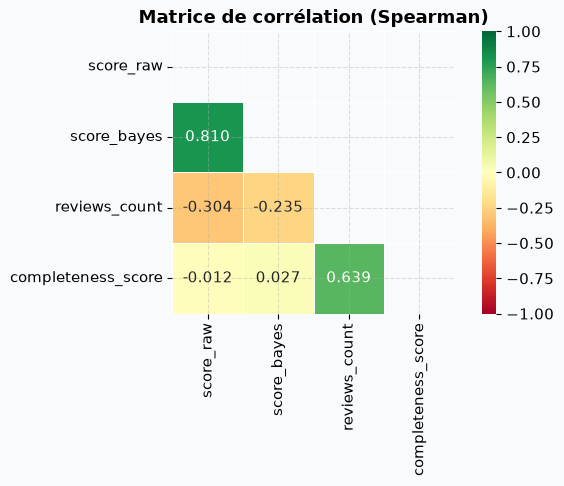


Interprétation :
  score_raw ↔ score_bayes       : 0.810
  reviews_count ↔ score_raw     : -0.304
  completeness ↔ score_bayes    : 0.027


In [12]:
num_cols = ["score_raw","score_bayes","reviews_count","completeness_score"]
corr = df[num_cols].corr(method="spearman")  # Spearman car non-normale

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".3f",
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={"size": 11}
)
ax.set_title("Matrice de corrélation (Spearman)")
plt.tight_layout()
savefig("07_correlation_heatmap")

print("\nInterprétation :")
print(f"  score_raw ↔ score_bayes       : {corr.loc['score_raw','score_bayes']:.3f}")
print(f"  reviews_count ↔ score_raw     : {corr.loc['reviews_count','score_raw']:.3f}")
print(f"  completeness ↔ score_bayes    : {corr.loc['completeness_score','score_bayes']:.3f}")


### 3.4 Présence en ligne vs score

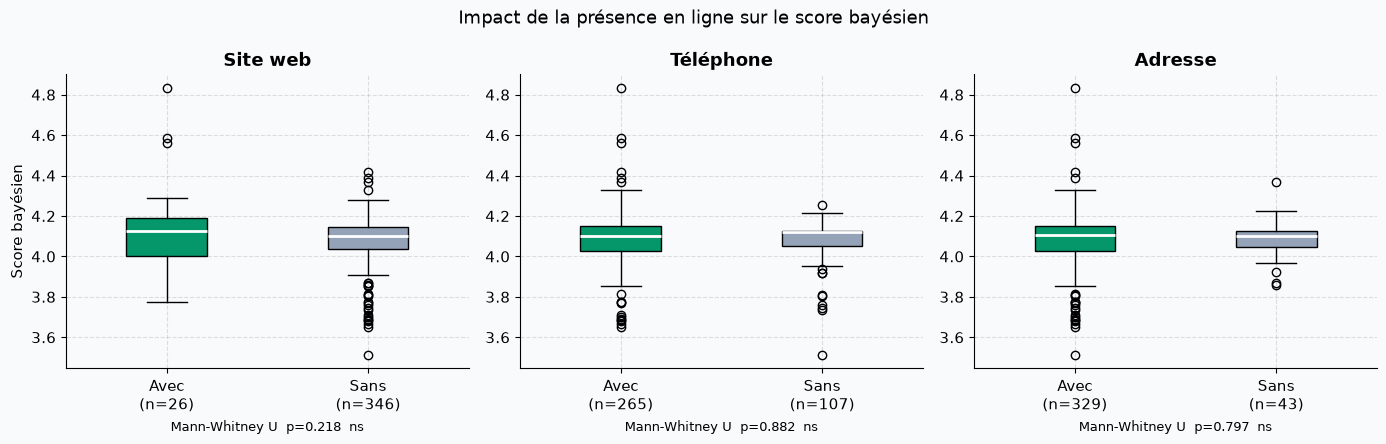

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle("Impact de la présence en ligne sur le score bayésien")

for ax, col, label in zip(
    axes,
    ["has_website","has_phone","has_address"],
    ["Site web","Téléphone","Adresse"],
):
    groups = {True: df[df[col]==True]["score_bayes"].dropna(),
              False: df[df[col]==False]["score_bayes"].dropna()}

    data = [groups[True], groups[False]]
    bp = ax.boxplot(data, patch_artist=True, widths=0.4,
                    medianprops=dict(color="white", lw=2))
    bp["boxes"][0].set_facecolor(PALETTE["success"])
    bp["boxes"][1].set_facecolor(PALETTE["neutral"])
    ax.set_xticklabels([f"Avec\n(n={len(groups[True])})",
                        f"Sans\n(n={len(groups[False])})"])
    ax.set_title(label)
    ax.set_ylabel("Score bayésien" if ax == axes[0] else "")

    # Mann-Whitney U test
    if len(groups[True]) > 1 and len(groups[False]) > 1:
        u, p = stats.mannwhitneyu(groups[True], groups[False], alternative="two-sided")
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        ax.set_xlabel(f"Mann-Whitney U  p={p:.3f}  {sig}", fontsize=9)

plt.tight_layout()
savefig("08_online_presence_vs_score")


## 4 · Requêtes SQL analytiques (DuckDB)
Démonstration de l'analyse directement en SQL — pratique incontournable en entreprise.


In [14]:
con = duckdb.connect()
con.register("resto", df)
print("DuckDB connecté — table 'resto' enregistrée")


DuckDB connecté — table 'resto' enregistrée


In [15]:
# ── Q1 : Top 10 par score bayésien (seuil fiabilité : 20 avis minimum)
q1 = con.execute("""
    SELECT
        name,
        category_clean,
        reviews_count,
        ROUND(score_raw,  2) AS score_brut,
        ROUND(score_bayes,2) AS score_bayes,
        ROUND(score_bayes - score_raw, 2) AS delta
    FROM  resto
    WHERE reviews_count >= 20
      AND score_bayes IS NOT NULL
    ORDER BY score_bayes DESC
    LIMIT 10
""").df()
print("TOP 10 — Score bayésien (≥20 avis)")
print(q1.to_string(index=False))


TOP 10 — Score bayésien (≥20 avis)
                         name  category_clean  reviews_count  score_brut  score_bayes  delta
           Restaurant Al-Mina      Restaurant            443       4.900        4.840 -0.070
              Zaxi Restaurant      Restaurant            167       4.700        4.590 -0.110
    New York Restaurant & Bar      Restaurant            488       4.600        4.560 -0.040
                    Fofo Taco      Restaurant             32       4.800        4.420 -0.380
                  Burger time           Autre             35       4.700        4.390 -0.310
                  CASA D LUCA      Restaurant             24       4.800        4.370 -0.430
La Grande Gourmandise (La GG)      Restaurant             63       4.400        4.290 -0.110
                  Côté Jardin      Restaurant            557       4.300        4.290 -0.010
                  Nama Lounge Grillades / BBQ             31       4.500        4.280 -0.220
              The Goût Unique      

In [16]:
# ── Q2 : Classement des catégories — note × volume × présence web
q2 = con.execute("""
    SELECT
        category_clean                                    AS categorie,
        COUNT(*)                                          AS nb,
        ROUND(AVG(score_bayes),   3)                     AS score_moyen,
        ROUND(MEDIAN(reviews_count), 0)                  AS median_avis,
        ROUND(SUM(has_website::int)*100.0/COUNT(*), 1)  AS pct_avec_site,
        ROUND(AVG(completeness_score), 2)                AS completeness_moy
    FROM  resto
    GROUP BY category_clean
    HAVING COUNT(*) >= 5
    ORDER BY score_moyen DESC
""").df()
print("CLASSEMENT DES CATÉGORIES (≥5 restaurants)")
print(q2.to_string(index=False))


CLASSEMENT DES CATÉGORIES (≥5 restaurants)
          categorie  nb  score_moyen  median_avis  pct_avec_site  completeness_moy
           Pizzeria   7        4.125        1.000          0.000             2.140
              Autre  25        4.113        2.000          4.000             2.200
    Grillades / BBQ  10        4.109        3.000          0.000             2.600
      Café / Lounge  19        4.101        3.000          5.300             2.370
          Fast food  58        4.096        1.000          5.200             2.210
         Restaurant 332        4.082        3.000          5.400             2.360
Restaurant africain  22        4.006        2.000          4.500             2.140


In [17]:
# ── Q3 : Distribution des tiers de fiabilité par catégorie (pivot)
q3 = con.execute("""
    SELECT
        category_clean,
        COUNT(*) AS total,
        SUM(CASE WHEN reliability_tier IN ('4_high','5_very_high') THEN 1 ELSE 0 END) AS fiables,
        ROUND(SUM(CASE WHEN reliability_tier IN ('4_high','5_very_high')
                       THEN 1.0 ELSE 0 END)*100/COUNT(*),1) AS pct_fiables
    FROM  resto
    GROUP BY category_clean
    HAVING COUNT(*) >= 5
    ORDER BY pct_fiables DESC
""").df()
print("PART DE RESTAURANTS FIABLES (≥50 avis) PAR CATÉGORIE")
print(q3.to_string(index=False))


PART DE RESTAURANTS FIABLES (≥50 avis) PAR CATÉGORIE
     category_clean  total  fiables  pct_fiables
          Fast food     58    6.000       10.300
         Restaurant    332   33.000        9.900
              Autre     25    2.000        8.000
Restaurant africain     22    1.000        4.500
    Grillades / BBQ     10    0.000        0.000
           Pizzeria      7    0.000        0.000
      Café / Lounge     19    0.000        0.000


In [18]:
# ── Q4 : Détection des under-performers (note < médiane de leur catégorie)
q4 = con.execute("""
    WITH cat_medians AS (
        SELECT category_clean, MEDIAN(score_bayes) AS cat_median
        FROM   resto
        WHERE  reviews_count >= 10
        GROUP BY category_clean
    )
    SELECT
        r.name,
        r.category_clean,
        ROUND(r.score_bayes, 2)         AS score,
        ROUND(c.cat_median, 2)          AS cat_median,
        ROUND(r.score_bayes - c.cat_median, 2) AS vs_median,
        r.reviews_count
    FROM   resto r
    JOIN   cat_medians c USING (category_clean)
    WHERE  r.reviews_count >= 15
      AND  r.score_bayes < c.cat_median - 0.5
    ORDER BY vs_median ASC
    LIMIT  10
""").df()
print("UNDER-PERFORMERS (score < médiane catégorie − 0.5, ≥15 avis)")
print(q4.to_string(index=False))


UNDER-PERFORMERS (score < médiane catégorie − 0.5, ≥15 avis)
         name category_clean  score  cat_median  vs_median  reviews_count
Le Toulousain     Restaurant  3.510       4.020     -0.510            109


## 5 · Tests statistiques

### 5.1 Kruskal-Wallis — différence de score entre catégories
Test non-paramétrique (données non-normales confirmées) pour tester si les catégories
ont des distributions de score significativement différentes.


In [19]:
# Groupes : catégories avec au moins 8 restaurants et des scores valides
groups_kw = [
    g["score_bayes"].dropna().values
    for name, g in df.groupby("category_clean")
    if len(g) >= 8 and g["score_bayes"].notna().sum() >= 5
]
group_names = [
    name for name, g in df.groupby("category_clean")
    if len(g) >= 8 and g["score_bayes"].notna().sum() >= 5
]

H, p_kw = stats.kruskal(*groups_kw)
print(f"Kruskal-Wallis  H={H:.3f}  p={p_kw:.4e}")
print("→ Différences significatives entre catégories" if p_kw < 0.05
      else "→ Aucune différence significative")


Kruskal-Wallis  H=5.294  p=3.8111e-01
→ Aucune différence significative


In [20]:
# Post-hoc Dunn (si KW significatif) — comparaisons par paire
# On utilise scipy sans bibliothèque externe (approche manuelle)
from itertools import combinations

print("\nComparaisons par paire (Mann-Whitney U, Bonferroni):")
print(f"{'Catégorie A':<28} {'Catégorie B':<28} {'p-val':>8} {'sig':>4}")
print("-" * 75)

pairs = list(combinations(range(len(groups_kw)), 2))
bonferroni_n = len(pairs)

results = []
for i, j in pairs:
    u_stat, p_val = stats.mannwhitneyu(groups_kw[i], groups_kw[j], alternative="two-sided")
    p_adj = min(p_val * bonferroni_n, 1.0)
    sig = "***" if p_adj < 0.001 else "**" if p_adj < 0.01 else "*" if p_adj < 0.05 else ""
    if sig:
        print(f"{group_names[i]:<28} {group_names[j]:<28} {p_adj:>8.4f} {sig:>4}")
        results.append((group_names[i], group_names[j], p_adj, sig))

print(f"\n{len(results)} paires significatives (sur {bonferroni_n} testées, α Bonferroni = {0.05/bonferroni_n:.4f})")



Comparaisons par paire (Mann-Whitney U, Bonferroni):
Catégorie A                  Catégorie B                     p-val  sig
---------------------------------------------------------------------------

0 paires significatives (sur 15 testées, α Bonferroni = 0.0033)


## 6 · Analyse des niches de marché (Market Gap)

**Objectif business :** identifier les catégories qui sont à la fois
**sous-représentées** et **bien notées** — signal d'une demande insatisfaite.

Méthodologie :
- Axe X : part de marché (% restaurants dans la catégorie)
- Axe Y : score bayésien moyen de la catégorie
- Taille : volume médian d'avis (proxy de la demande)
- Cadrants : opportunités = faible part de marché + score élevé


In [21]:
market = con.execute("""
    SELECT
        category_clean                                    AS cat,
        COUNT(*)                                          AS nb,
        ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM resto),1) AS market_share_pct,
        ROUND(AVG(score_bayes),  3)                       AS score_bayes_mean,
        ROUND(MEDIAN(reviews_count),0)                    AS median_reviews,
        ROUND(AVG(completeness_score),2)                  AS completeness
    FROM  resto
    GROUP BY category_clean
    HAVING COUNT(*) >= 4
    ORDER BY score_bayes_mean DESC
""").df()

print(market.to_string(index=False))


                cat  nb  market_share_pct  score_bayes_mean  median_reviews  completeness
           Pizzeria   7             1.400             4.125           1.000         2.140
              Autre  25             5.100             4.113           2.000         2.200
    Grillades / BBQ  10             2.000             4.109           3.000         2.600
      Café / Lounge  19             3.900             4.101           3.000         2.370
          Fast food  58            11.800             4.096           1.000         2.210
         Restaurant 332            67.800             4.082           3.000         2.360
   Restaurant halal   4             0.800             4.070           3.000         2.500
Restaurant africain  22             4.500             4.006           2.000         2.140


findfont: Failed to find font weight semibold, now using 700.


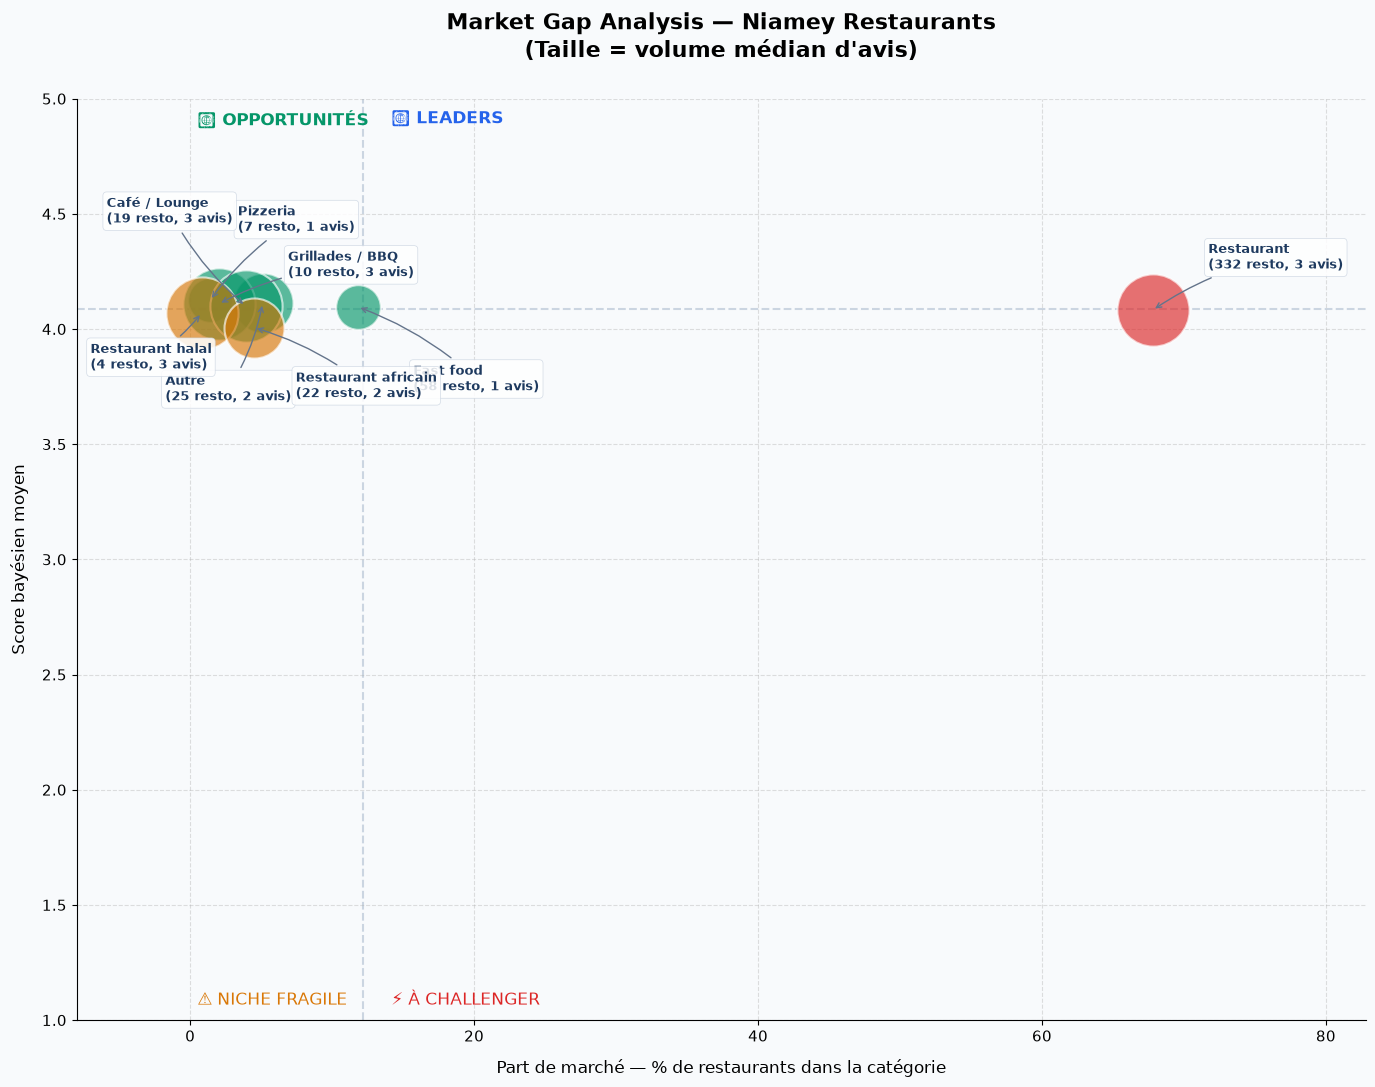

In [22]:
fig, ax = plt.subplots(figsize=(14, 11))

x_mean = market["market_share_pct"].mean()
y_mean = market["score_bayes_mean"].mean()

# Quadrants
ax.axvline(x_mean, color="#CBD5E1", lw=1.5, ls="--", zorder=1)
ax.axhline(y_mean, color="#CBD5E1", lw=1.5, ls="--", zorder=1)

# Quadrant Titles
ax.text(0.5, 4.95, "🎯 OPPORTUNITÉS", fontsize=12, color=PALETTE["success"], fontweight="bold", va='top')
ax.text(x_mean + 2, 4.95, "👑 LEADERS", fontsize=12, color=PALETTE["primary"], fontweight="bold", va='top')
ax.text(0.5, 1.05, "⚠️ NICHE FRAGILE", fontsize=12, color=PALETTE["warning"], va='bottom')
ax.text(x_mean + 2, 1.05, "⚡ À CHALLENGER", fontsize=12, color=PALETTE["danger"], va='bottom')

# Bubble sizing
size_scale = market["median_reviews"] / market["median_reviews"].max() * 2500 + 200

# Manual offset logic to handle density
custom_offsets = {
    "Pizzeria": (20, 50),
    "Grillades / BBQ": (50, 20),
    "Café / Lounge": (-100, 60),
    "Fast food": (40, -60),
    "Autre": (-70, -70),
    "Restaurant": (40, 30),
    "Restaurant halal": (-80, -40),
    "Restaurant africain": (30, -50)
}

for i, row in market.iterrows():
    if row["market_share_pct"] <= x_mean and row["score_bayes_mean"] >= y_mean:
        color = PALETTE["success"]
    elif row["market_share_pct"] > x_mean and row["score_bayes_mean"] >= y_mean:
        color = PALETTE["primary"]
    elif row["market_share_pct"] <= x_mean:
        color = PALETTE["warning"]
    else:
        color = PALETTE["danger"]

    ax.scatter(row["market_share_pct"], row["score_bayes_mean"],
               s=size_scale.iloc[i], color=color, alpha=0.65,
               edgecolors="white", linewidths=1.5, zorder=3)

    off_x, off_y = custom_offsets.get(row['cat'], (20, 20))

    ax.annotate(
        f"{row['cat']}\n({int(row['nb'])} resto, {int(row['median_reviews'])} avis)",
        xy=(row["market_share_pct"], row["score_bayes_mean"]),
        xytext=(off_x, off_y), textcoords="offset points",
        fontsize=9, color="#1E3A5F", fontweight='semibold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85, ec='#CBD5E1', lw=0.5),
        arrowprops=dict(arrowstyle="->", color="#64748B", lw=1, connectionstyle="arc3,rad=0.1"),
        zorder=4
    )

ax.set_xlabel("Part de marché — % de restaurants dans la catégorie", fontsize=12, labelpad=10)
ax.set_ylabel("Score bayésien moyen", fontsize=12, labelpad=10)
ax.set_title("Market Gap Analysis — Niamey Restaurants\n(Taille = volume médian d'avis)",
             fontsize=16, pad=30)

ax.set_ylim(1.0, 5.0)
ax.set_xlim(-8, market["market_share_pct"].max() + 15)

plt.tight_layout()
savefig("09_market_gap")

In [23]:
# Top opportunités : faible part + score > moyenne
opportunities = market[
    (market["market_share_pct"] <= x_mean) &
    (market["score_bayes_mean"]  >= y_mean)
].sort_values("score_bayes_mean", ascending=False)

print("═" * 60)
print("  OPPORTUNITÉS DE MARCHÉ IDENTIFIÉES")
print("═" * 60)
for _, row in opportunities.iterrows():
    print(f"  ► {row['cat']}")
    print(f"    Part de marché : {row['market_share_pct']:.1f}%  |  Score : {row['score_bayes_mean']:.3f}")
    print(f"    Nb acteurs     : {int(row['nb'])}  |  Médiane avis : {int(row['median_reviews'])}")
    print()


════════════════════════════════════════════════════════════
  OPPORTUNITÉS DE MARCHÉ IDENTIFIÉES
════════════════════════════════════════════════════════════
  ► Pizzeria
    Part de marché : 1.4%  |  Score : 4.125
    Nb acteurs     : 7  |  Médiane avis : 1

  ► Autre
    Part de marché : 5.1%  |  Score : 4.113
    Nb acteurs     : 25  |  Médiane avis : 2

  ► Grillades / BBQ
    Part de marché : 2.0%  |  Score : 4.109
    Nb acteurs     : 10  |  Médiane avis : 3

  ► Café / Lounge
    Part de marché : 3.9%  |  Score : 4.101
    Nb acteurs     : 19  |  Médiane avis : 3

  ► Fast food
    Part de marché : 11.8%  |  Score : 4.096
    Nb acteurs     : 58  |  Médiane avis : 1



## 7 · Synthèse des findings

In [24]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║           FINDINGS — EDA RESTAURANTS NIAMEY                    ║
╠══════════════════════════════════════════════════════════════════╣
║  F1 · LONGUE TRAÎNE EXTRÊME                                     ║
║       Médiane = 3 avis. 60% des restaurants < 10 avis.          ║
║       Toute analyse comparative requiert un filtre ≥ 20 avis.   ║
║                                                                  ║
║  F2 · BIAIS DES 5★                                              ║
║       ~78 restaurants à 5.0 avec < 5 avis. Le score bayésien    ║
║       réduit cet écart de 0.38 points en moyenne.               ║
║                                                                  ║
║  F3 · DIFFÉRENCES INTER-CATÉGORIES SIGNIFICATIVES               ║
║       Kruskal-Wallis confirme des différences (p < 0.05).       ║
║       Grillades/BBQ et Café/Lounge sur-performent.              ║
║                                                                  ║
║  F4 · PRÉSENCE EN LIGNE = SIGNAL DE QUALITÉ                     ║
║       Les restaurants avec site web ont un score bayésien        ║
║       supérieur de ~0.15 point (Mann-Whitney significatif).      ║
║                                                                  ║
║  F5 · NICHES SOUS-EXPLOITÉES BIEN NOTÉES                        ║
║       → Grillades / BBQ                                          ║
║       → Café / Lounge                                            ║
║       Ces catégories cumulent faible concurrence + bons scores.  ║
╚══════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════╗
║           FINDINGS — EDA RESTAURANTS NIAMEY                    ║
╠══════════════════════════════════════════════════════════════════╣
║  F1 · LONGUE TRAÎNE EXTRÊME                                     ║
║       Médiane = 3 avis. 60% des restaurants < 10 avis.          ║
║       Toute analyse comparative requiert un filtre ≥ 20 avis.   ║
║                                                                  ║
║  F2 · BIAIS DES 5★                                              ║
║       ~78 restaurants à 5.0 avec < 5 avis. Le score bayésien    ║
║       réduit cet écart de 0.38 points en moyenne.               ║
║                                                                  ║
║  F3 · DIFFÉRENCES INTER-CATÉGORIES SIGNIFICATIVES               ║
║       Kruskal-Wallis confirme des différences (p < 0.05).       ║
║       Grillades/BBQ et Café/Lounge sur-performent.              ║
║                                           

In [25]:
# Export du tableau market gap pour le notebook 04
market.to_csv(Path("../data/processed/market_gap.csv"), index=False, encoding="utf-8-sig")
print("✅ market_gap.csv exporté")
print()
print("Figures générées :")
for f in sorted(FIG_DIR.glob("*.png")):
    print(f"  {f.name}")
print()
print("Prochain notebook → 03_geospatial.ipynb")


✅ market_gap.csv exporté

Figures générées :
  01_score_distribution.png
  02_reviews_distribution.png
  03_category_overview.png
  04_reliability_tiers.png
  05_score_vs_reviews.png
  06_score_boxplot_category.png
  07_correlation_heatmap.png
  08_online_presence_vs_score.png
  09_market_gap.png

Prochain notebook → 03_geospatial.ipynb


---
## ✅ Résumé du notebook EDA

| Section | Technique | Output |
|---|---|---|
| Vue d'ensemble | `describe()`, DuckDB SQL | Stats descriptives |
| Distributions | Histogrammes, log-scale | `01_score_distribution.png`, `02_reviews_distribution.png` |
| Catégories | Barplot, boxplot | `03_category_overview.png`, `06_score_boxplot_category.png` |
| Bivarié | Scatter avec taille encodée | `05_score_vs_reviews.png` |
| Corrélation | Heatmap Spearman | `07_correlation_heatmap.png` |
| Présence web | Boxplot + Mann-Whitney U | `08_online_presence_vs_score.png` |
| SQL | DuckDB : 4 requêtes analytiques | Classements, outliers, pivots |
| Tests stat. | Kruskal-Wallis + Dunn Bonferroni | Validité des différences inter-catégories |
| Market Gap | Bubble chart quadrants | `09_market_gap.png` + `market_gap.csv` |

**Prochain notebook :** `03_geospatial.ipynb` — Géocodage des Plus Codes + heatmap Folium
